# Rating Curve Assessment
JOHN CRAMBLITT | 7/5/2024

This notebook is used to plot stage-Q data from the period with unprocessed levelogger data against the previously developed rating curves to see if the rating curves still capture the relationship between stage and Q properly (i.e. check if the rating curves need to be updated). 

Author of Template and Underlying Code: Joe Ammatelli | (jamma@uw.edu) | August 2022

## Import Libraries
**Analyst TODO**: Run cell

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns
import sys

sys.path.insert(0, os.path.abspath(os.path.join('..', 'src')))

import config

sys.path.remove(os.path.abspath(os.path.join('..', 'src')))

In [2]:
from datetime import datetime, timedelta 

## Configure Plotting Preferences
**Analyst TODO:**
* Choose plotting backend:
    - Interactive (recommended): uncomment `%matplotlib notebook` and `FIGSIZE=NONE`; comment out `FIGSIZE = config.FIGSIZE`
    - Inline: comment out `%matplotlib notebook` `FIGSIZE=NONE`; uncomment `FIGSIZE = config.FIGSIZE`

In [3]:
#%matplotlib notebook
sns.set_theme()

## Define Utility Functions
**Analyst TODO:** Run cells

In [4]:
def plot_rating_curve(ax, site, hrange):
    ax.set_title('Rating Curve for ' + config.SITE_LONGNAME[site])
    ax.set_ylabel('Stage (m)')
    ax.set_xlabel('Q (m^3s^-1)')
    
    h = np.linspace(hrange[0], hrange[1], 100)
    Q = [config.RATING_CURVES[site](hi) for hi in h]
    
    ax.plot(Q, h, label='rating curve')
    ax.legend()

In [5]:
def plot_site_stageQ(ax, site, stageQ, color, label,offset=0):
    site_stageQ = stageQ.loc[stageQ['Site Name'] == config.SITE_SHORTNAME[site]]    
    ax.scatter(site_stageQ['Measured Q (cms)'], site_stageQ['Stage (m)'] - offset, c=color, label=label)
    ax.legend()

## Load Stage/Q Data (all sites) for given span
**Analyst TODO**:
* Read data for each year of interest: add filename string to `fns` for each site
* Combine datasets into one dataframe
* convert units as necessary

In [6]:
# Read data for each year of interest
fns = ['tum_stageQ_2021.csv','tum_stageQ_2022.csv','tum_stageQ_2023.csv']  # add file names here (not full path, just name of file)
#fns = ['tum_stageQ_2021.csv','tum_stageQ_2022.csv']  # add file names here (not full path, just name of file)

dfs = []

for fn in fns:
    path = os.path.join('..', 'compiled_data', 'stageQ', fn)
    dfs.append(pd.read_csv(path))

# Combine datasets into one dataframe
stageQ = pd.concat(dfs, ignore_index=True)

# convert units as necessary
FT_TO_M = 0.3048
stageQ = stageQ.rename(columns={'Stage (ft)' :'Stage (m)'})
stageQ['Stage (m)'] *= FT_TO_M

CFS_TO_CMS = 0.028316847
stageQ = stageQ.rename(columns={'Measured Q (cfs)' :'Measured Q (cms)'})
stageQ['Measured Q (cms)'] *= CFS_TO_CMS

# view dataframe

stageQ

,Site Name,Field visit date,Field task,Q Method,Stage (m),Measured Q (cms)
0,Tuolumne@120,11/10/2020,Download?,NaN,NaN,NaN
1,Tuolumne@120,5/12/2021,Discharge,ADCP,1.438656,10.562184
2,Tuolumne@120,6/8/2021,Discharge,ADCP,1.173480,NaN
3,Tuolumne@120,7/15/2021,Discharge,ADV,0.896112,NaN
4,Tuolumne@120,8/12/2021,"Discharge, logger swap",ADV,NaN,NaN
5,Tuolumne@120,8/26/2021,Discharge,ADV,0.774192,0.191988
6,LyellAbvTB,6/15/2021,Discharge,ADCP,2.862072,2.041928
7,LyellAbvTB,7/14/2021,Discharge,ADV,NaN,NaN
8,LyellAbvTB,7/26/2021,"Discharge, logger swap, survey",ADV,2.834640,NaN
9,LyellAbvTB,8/24/2021,Discharge,ADV,2.743200,0.180945


## For each site, plot rating curve and data points
**Analyst TODO** Plot site of interest (or for which valid rating curves exist)
* List the numeric site codes you wish to plot in the `sites` list
    * 0 : Lyell Below Maclure
    * 1 : Lyell Above Twin Bridges
    * 2 : Dana Fork at Bug Camp
    * 3 : Tuolumne River at Highway 120
    * 4 : Budd Creek
    * 5 : Delaney Above PCT
* For each site, add a tuple to the hranges list representing the lower and upper bound of h ranges to plot. The i'th entry of hranges should correspond to the i'th entry of sites

C:\Users\johnc\Tuolumne\tum_hydro_qc\src\config.py:52: RuntimeWarning: invalid value encountered in scalar power
  RATING_CURVES = {0 : (lambda h: (5.08516 * (h - 1.9383)**1.49088 if h < 2.29893 else
C:\Users\johnc\Tuolumne\tum_hydro_qc\src\config.py:54: RuntimeWarning: invalid value encountered in scalar power
  1 : (lambda h: (13.0679 * (h - 0.189547)**1.53746 if h < 0.545817 else
C:\Users\johnc\Tuolumne\tum_hydro_qc\src\config.py:57: RuntimeWarning: invalid value encountered in scalar power
  2 : (lambda h: (9.81848 * (h - 0.218727)**1.48825 if h < 0.354118 else
C:\Users\johnc\Tuolumne\tum_hydro_qc\src\config.py:60: RuntimeWarning: invalid value encountered in scalar power
  3 : (lambda h: (34.3522 * (h - 0.7639)**1.465 if h < 0.8011 else


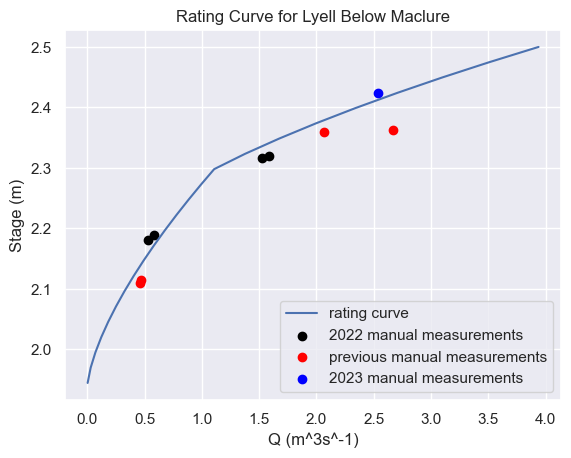

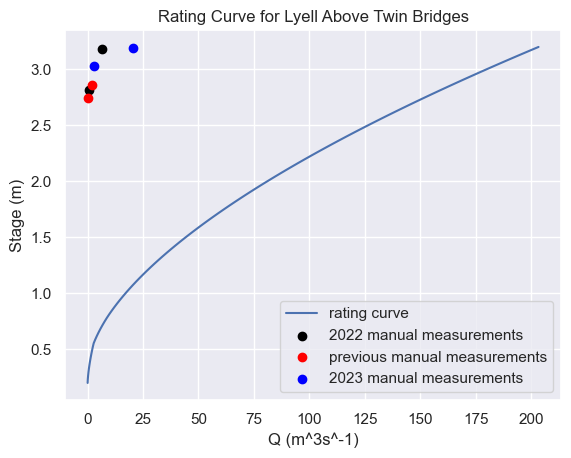

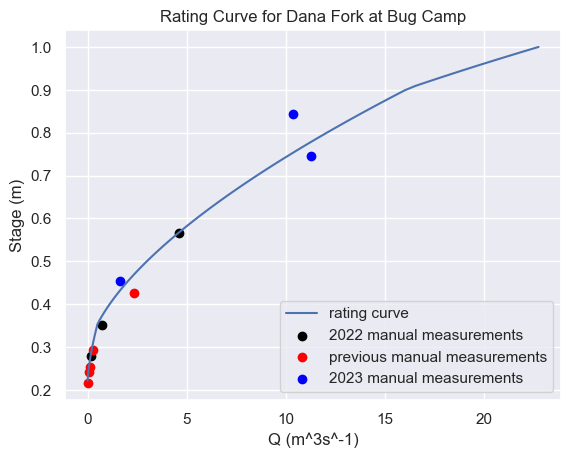

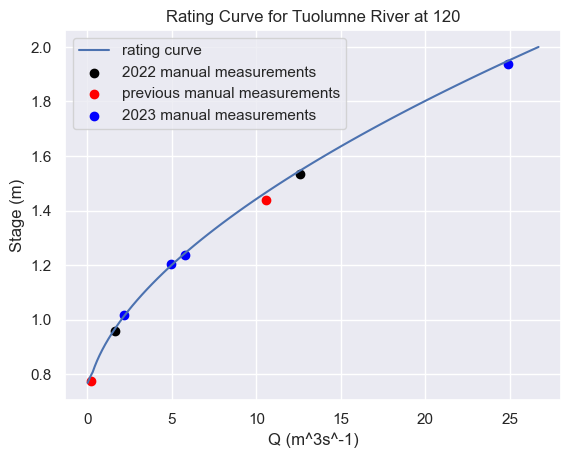

In [7]:
# add sites here
# e.g. sites = [0, 1, 3]
sites = [0,1,2,3]

# add h ranges here
# e.g. hranges = [(1.8, 2.5), (0, 2), (0, 3)]
hranges = [(0,2.5),(0,3.2),(0,1),(0,2)]
#hranges = [(2.1,2.5),(2.7,3.2),(0,2),(0.9,1.6)]

for site, hrange in zip(sites, hranges):
    fig, ax = plt.subplots()
    plot_rating_curve(ax, site, hrange)
    plot_site_stageQ(ax, site, stageQ.iloc[33:44],color='black',label='2022 manual measurements')
    plot_site_stageQ(ax, site, stageQ.iloc[:33],color='red',label='previous manual measurements')
    plot_site_stageQ(ax, site, stageQ.iloc[44:],color='blue',label='2023 manual measurements')

**NOTES:** Rating curve for Tuolumne@120 looks great. At Dana Fork, meausrements appear to follow natural spread at higher flows, so rating curve is okay. At LyellBlwMaclure, only one measurement is available from WY2023, but it follows the rating curve. LyellAbvTB needs further analysis. 

## Conduct Site Specific Analysis
**Analyst TODO**: Complete site specific analysis as necessary

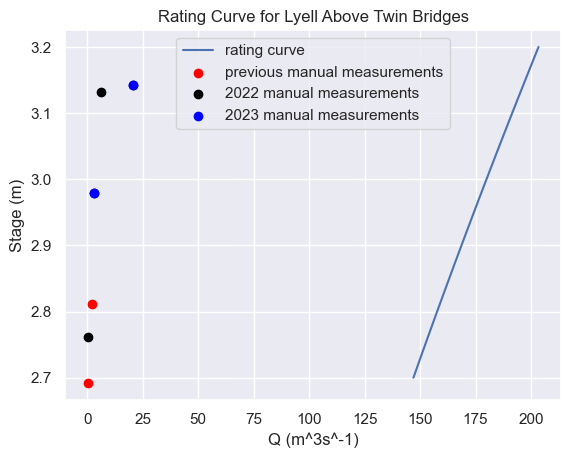

In [8]:
site = 1
hrange = (2.7,3.2)
offset = 5.11383796903084 /100 # obtained from stitching step

fig, ax = plt.subplots()
plot_rating_curve(ax, site, hrange)
plot_site_stageQ(ax, site, stageQ[:33], offset=offset,color='red',label='previous manual measurements')
plot_site_stageQ(ax, site, stageQ[33:], offset=offset,color='black',label='2022 manual measurements')
plot_site_stageQ(ax, site, stageQ[49:], offset=offset,color='blue',label='2023 manual measurements')

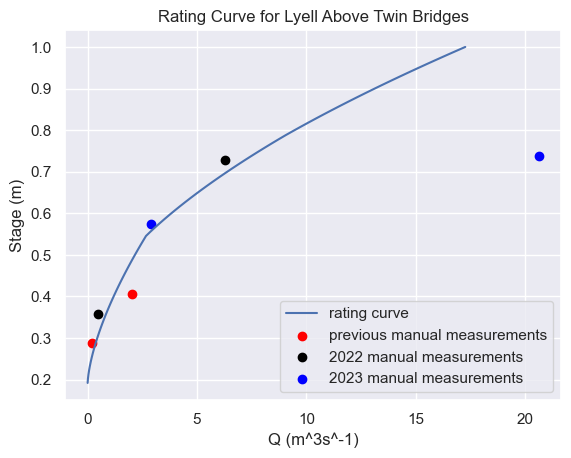

In [9]:
site = 1
hrange = (0,1)
offset = 245.5756 / 100  # obtained from stitching step

fig, ax = plt.subplots()
plot_rating_curve(ax, site, hrange)
plot_site_stageQ(ax, site, stageQ[:33], offset=offset,color='red',label='previous manual measurements')
plot_site_stageQ(ax, site, stageQ[33:49], offset=offset,color='black',label='2022 manual measurements')
plot_site_stageQ(ax, site, stageQ[49:], offset=offset,color='blue',label='2023 manual measurements')

After correcting for offset, one manual stage measurements still doesn't align with rating curve. Check against co-incident automated stage measurement to check for error in  manual stage meausrement.

In [10]:
fp = "C:\\Users\\johnc\\Tuolumne\\tum_hydro_qc\\output\\processed_data\\LyellAbvTB_timeseries_stage_Q_T_2005_2023.csv"
automated_measurements = pd.read_csv(fp,infer_datetime_format=True)
automated_measurements['date_time(UTC:PDT+7)'] = pd.to_datetime(automated_measurements['date_time(UTC:PDT+7)'])
automated_measurements.head()

C:\Users\johnc\AppData\Local\Temp\ipykernel_89864\1827469005.py:2: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  automated_measurements = pd.read_csv(fp,infer_datetime_format=True)


,date_time(UTC:PDT+7),raw_pressure(cm),barocorrected_pressure(cm),adjusted_stage(cm),estimated_discharge(cms),water_temperature(deg_C),discharge_flag
0,2005-09-03 01:00:00,96.6,31.9,31.9,0.56,16.82,0
1,2005-09-03 01:30:00,96.7,32.0,32.0,0.57,16.75,0
2,2005-09-03 02:00:00,96.5,31.5,31.5,0.54,16.58,0
3,2005-09-03 02:30:00,96.5,31.3,31.3,0.52,16.35,0
4,2005-09-03 03:00:00,96.5,31.0,31.0,0.50,16.06,0


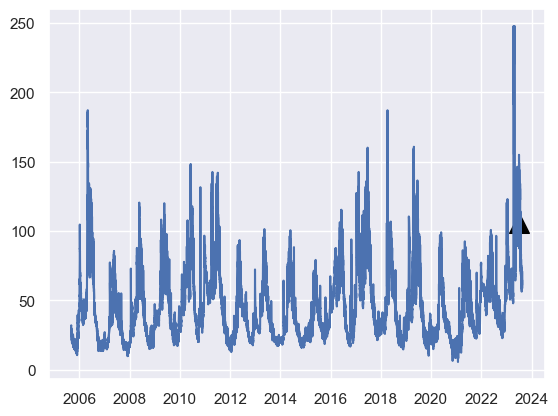

In [11]:
measurement_time = pd.to_datetime('2023-07-06 15:00:00')+timedelta(hours=7)
automated_stage = automated_measurements.loc[automated_measurements['date_time(UTC:PDT+7)']==measurement_time]['adjusted_stage(cm)']
plt.plot(automated_measurements['date_time(UTC:PDT+7)'],automated_measurements['adjusted_stage(cm)'])
plt.scatter(measurement_time,automated_stage,marker='^',s=200,c='black')

C:\Users\johnc\Tuolumne\tum_hydro_qc\src\config.py:54: RuntimeWarning: invalid value encountered in scalar power
  1 : (lambda h: (13.0679 * (h - 0.189547)**1.53746 if h < 0.545817 else


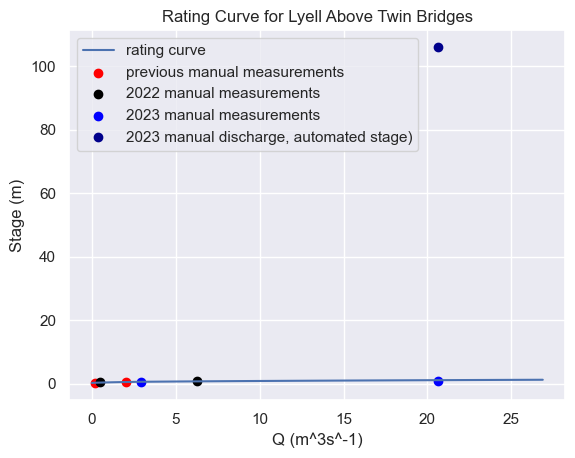

In [12]:
CM_TO_M = 0.01
automated_stage_m = automated_stage*CM_TO_M

#CFS_TO_CMS = 0.028316847
manual_discharge = stageQ[49:50]['Measured Q (cms)']
#manual_discharge *= CFS_TO_CMS

site = 1
hrange = (0,1.2)
offset = 245.5756 / 100  # obtained from stitching step

fig, ax = plt.subplots()
plot_rating_curve(ax, site, hrange)
plot_site_stageQ(ax, site, stageQ[:33], offset=offset,color='red',label='previous manual measurements')
plot_site_stageQ(ax, site, stageQ[33:49], offset=offset,color='black',label='2022 manual measurements')
plot_site_stageQ(ax, site, stageQ[49:], offset=offset,color='blue',label='2023 manual measurements')
ax.scatter(manual_discharge,automated_stage, color='darkblue',label='2023 manual discharge, automated stage)')
ax.legend()

**NOTE:** By plotting manual discharge against the automated stage measurement taken at the same time, LyellAbvTB follows the rating curve. 

In [13]:
fp = "C:\\Users\\johnc\\Tuolumne\\tum_hydro_qc\\output\\processed_data\\DanaFk@BugCamp_timeseries_stage_Q_T_2005_2023.csv"
automated_measurements_dana = pd.read_csv(fp,infer_datetime_format=True)
automated_measurements_dana['date_time(UTC:PDT+7)'] = pd.to_datetime(automated_measurements_dana['date_time(UTC:PDT+7)'])
automated_measurements_dana.head()

C:\Users\johnc\AppData\Local\Temp\ipykernel_89864\3077788324.py:2: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  automated_measurements_dana = pd.read_csv(fp,infer_datetime_format=True)


,date_time(UTC:PDT+7),raw_pressure(cm),barocorrected_pressure(cm),adjusted_stage(cm),estimated_discharge(cms),water_temperature(deg_C),discharge_flag
0,2005-09-01 22:00:00,86.3,22.0,22.0,0.16,13.53,0
1,2005-09-01 22:30:00,86.4,21.9,21.9,0.16,13.82,0
2,2005-09-01 23:00:00,86.3,22.0,22.0,0.16,14.08,0
3,2005-09-01 23:30:00,86.5,22.0,22.0,0.16,14.22,0
4,2005-09-02 00:00:00,86.2,22.5,22.5,0.18,14.29,0


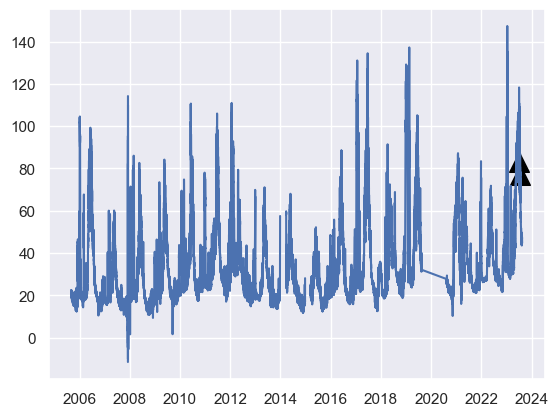

In [14]:
measurement_time_dana_1 = pd.to_datetime('2023-07-06 13:00:00')+timedelta(hours=7)
automated_stage_dana_1 = automated_measurements_dana.loc[automated_measurements_dana['date_time(UTC:PDT+7)']==measurement_time_dana_1]['adjusted_stage(cm)']

measurement_time_dana_2 = pd.to_datetime('2023-07-10 14:30:00')+timedelta(hours=7)
automated_stage_dana_2 = automated_measurements_dana.loc[automated_measurements_dana['date_time(UTC:PDT+7)']==measurement_time_dana_2]['adjusted_stage(cm)']

plt.plot(automated_measurements_dana['date_time(UTC:PDT+7)'],automated_measurements_dana['adjusted_stage(cm)'])
plt.scatter(measurement_time_dana_1,automated_stage_dana_1,marker='^',s=200,c='black')
plt.scatter(measurement_time_dana_2,automated_stage_dana_2,marker='^',s=200,c='black')

C:\Users\johnc\Tuolumne\tum_hydro_qc\src\config.py:57: RuntimeWarning: invalid value encountered in scalar power
  2 : (lambda h: (9.81848 * (h - 0.218727)**1.48825 if h < 0.354118 else


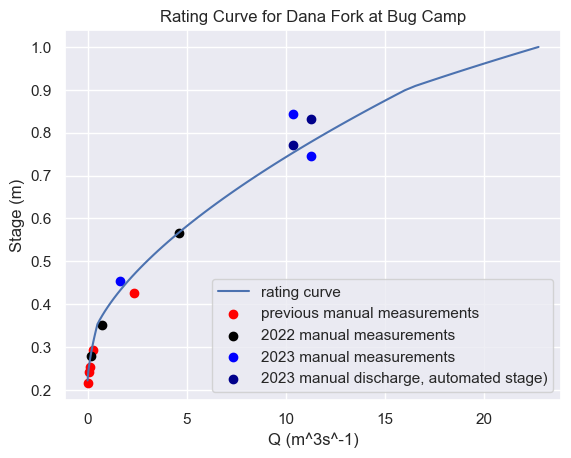

In [15]:
CM_TO_M = 0.01
automated_stage_dana_1_m = automated_stage_dana_1*CM_TO_M
automated_stage_dana_2_m = automated_stage_dana_2*CM_TO_M

#CFS_TO_CMS = 0.028316847
manual_discharge_dana_1 = stageQ[51:52]['Measured Q (cms)']
manual_discharge_dana_2 = stageQ[52:53]['Measured Q (cms)']
#manual_discharge *= CFS_TO_CMS

site = 2
hrange = (0,1)

fig, ax = plt.subplots()
plot_rating_curve(ax, site, hrange)
plot_site_stageQ(ax, site, stageQ[10:33],color='red',label='previous manual measurements')
plot_site_stageQ(ax, site, stageQ[33:49], color='black',label='2022 manual measurements')
plot_site_stageQ(ax, site, stageQ[49:], color='blue',label='2023 manual measurements')
ax.scatter(manual_discharge_dana_1,automated_stage_dana_1_m, color='darkblue',label='2023 manual discharge, automated stage)')
ax.scatter(manual_discharge_dana_2,automated_stage_dana_2_m, color='darkblue')
ax.legend()

**NOTE:** Using automated stage measurements does not necessarily improve the fit to the rating curve, but does suggest the difference between automated and manual measurements includes the predicted rating curve for the point on 7/10/2023, and on 7/6/2023 the point moves closer to the rating curve.

#### **SUMMARY:** All rating curves validated for WY 2022 and 2023.